# ABC–XYZ Analysis & Product Segmentation

## Business Question
> "Which products drive our revenue — and how predictable is their demand?
> Are we serving retail consumers or wholesale buyers, and does that change
> how we should manage inventory?"

## Context
**Dataset:** UCI Online Retail II — a UK-based single-brand online giftware retailer covering transactions from December 2009 to December 2011.

The dataset contains ~1M raw invoice lines with fields: `Invoice`,
`StockCode`, `Description`, `Quantity`, `InvoiceDate`, `Price`,
`Customer ID`, and `Country`.

A key structural insight: **~22% of transactions have no Customer ID**, meaning they cannot be attributed to any individual buyer. Rather than discarding this revenue, we split the data into two layers so that product analysis remains complete while customer analysis stays accurate.

## What This Notebook Does

| Step | Description |
|------|-------------|
| **1. Load & Investigate** | Shape, dtypes, missing values, date range, cardinality |
| **2. Clean** | Remove cancellations, negative/zero quantity & price, special SKUs, NaN descriptions |
| **3. Two-Layer Architecture** | *Transaction Layer* (all valid rows, for revenue & product analysis) · *Customer Layer* (known Customer IDs only, for behavioral analysis) |
| **4. Wholesale vs. D2C Labeling** | Segment customers by average order quantity (threshold = 20 units/line); label transactions accordingly |
| **5. ABC Analysis** | Rank SKUs by cumulative revenue contribution → Class A (≤ 80%), B (80–95%), C (95–100%) |
| **6. XYZ Analysis** | Measure demand variability per SKU via Coefficient of Variation → X (CV < 0.5), Y (0.5–1.0), Z (CV > 1.0); minimum 3 active months required |
| **7. ABC–XYZ Matrix** | Merge both dimensions → 9 strategic segments; visualize as heatmap + Revenue vs. CV scatter plot |
| **8. Inventory Policy** | Map each segment to a recommended stocking and replenishment strategy |

## Outputs
| File | Description |
|------|-------------|
| `outputs/abc_xyz_classification.csv` | Master SKU table with ABC class, XYZ class, combined segment, total revenue, total quantity, CoV, active months |
| `outputs/charts/01_Wholesale vs D2C - Quantity Distribution.png` | Histogram of avg order quantity — basis for wholesale threshold |
| `outputs/charts/02_Monthly Revenue - Wholesale vs D2C vs Anonymous.png` | Stacked bar — monthly revenue split by customer segment |
| `outputs/charts/03_ABC Analysis Distribution of SKUs vs Revenue.png` | Pareto curve with A/B/C shading |
| `outputs/charts/04_ABC-XYZ Product Segmentation.png` | Heatmap (SKU count + revenue %) · Scatter (Revenue vs. CV) |

In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
# LOAD DATA
df = pd.read_csv('../data/online_retail_II.csv', quotechar='\x00', engine='python', on_bad_lines='skip')

print(f'\n=== DATA SHAPE ===')
print(f'Total Rows:     {df.shape[0]:,}')
print(f'Total Columns:  {df.shape[1]}')

print(f'\n=== DATA TYPE ===')
print(df.dtypes)

print(f'\n=== DATA SAMPLES ===')
df.head(10)



=== DATA SHAPE ===
Total Rows:     1,033,236
Total Columns:  8

=== DATA TYPE ===
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

=== DATA SAMPLES ===


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434`,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,"""489434",22041,"""""RECORD FRAME 7"""""""" SINGLE SIZE """"",48,2009-12-01 07:45:00,2.10,13085.0,"United Kingdom"""
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22195,HEART MEASURING SPOONS LARGE,24,2009-12-01 07:46:00,1.65,13085.0,United Kingdom


In [3]:
# TRANSFROM DATA

# Rename columns name
df = df.rename(columns={
    'Invoice': 'order_id',
    'StockCode': 'sku',
    'InvoiceDate': 'order_date',
    'Customer ID': 'customer_id'})

df.columns = df.columns.astype(str).str.lower()

# Remove " characters
for cols in df.columns:
    df[cols] = df[cols].astype(str).str.replace('"','', regex=False).str.strip()

# Conver data types
df['customer_id'] = df['customer_id'].astype(str).str.split('.').str[0].replace('nan', np.nan)
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

print(df.dtypes)
df.head()

order_id               object
sku                    object
description            object
quantity                int64
order_date     datetime64[ns]
price                 float64
customer_id            object
country                object
dtype: object


,order_id,sku,description,quantity,order_date,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434`,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,RECORD FRAME 7 SINGLE SIZE,48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [4]:
# DATA INVESTIGATION

print(f'\n === DATA QUALITY ===')
print(f'Total Rows:                 {df.shape[0]:,}')
print(f'Total Columns:              {df.shape[1]:,}')
print(f'Data Range:                 {df['order_date'].min().date()} - {df['order_date'].max().date()}')
print(f'Orders:                     {df['order_id'].nunique():,} unique values')
print(f'SKU:                        {df['sku'].nunique():,} unique values')
print(f'Customers:                  {df['customer_id'].nunique():,} unique values')

print(f'\n === MISSING VALUES ===')
for cols in df.columns:
    n = df[cols].isnull().sum()
    pct = n / len(df) * 100
    print(f'{cols:<15}{n:>8} missing ({pct:.2f}%)')

print(f'\n === NEGATIVE VALUES ===')
print(f'Negative Quantity:          {(df['quantity']<0).sum():,}')
print(f'Negative Price:             {(df['price']<0).sum():,}')
print(f'Zero Quantity:              {(df['quantity']==0).sum():,}')
print(f'Zero Price:                 {(df['price']==0).sum():,}')

print(f"\n=== CANCELLATIONS ===")
cancellations = df[df['order_id'].astype(str).str.startswith('C', na=False)]
print(f"Cancellation rows:          {len(cancellations):,} rows ({len(cancellations)/len(df):.2%})")


 === DATA QUALITY ===
Total Rows:                 1,033,236
Total Columns:              8
Data Range:                 2009-12-01 - 2011-12-04
Orders:                     52,850 unique values
SKU:                        5,276 unique values
Customers:                  5,921 unique values

 === MISSING VALUES ===
order_id              0 missing (0.00%)
sku                   0 missing (0.00%)
description           0 missing (0.00%)
quantity              0 missing (0.00%)
order_date            0 missing (0.00%)
price                 0 missing (0.00%)
customer_id      232623 missing (22.51%)
country               0 missing (0.00%)

 === NEGATIVE VALUES ===
Negative Quantity:          22,463
Negative Price:             5
Zero Quantity:              0
Zero Price:                 6,139

=== CANCELLATIONS ===
Cancellation rows:          19,045 rows (1.84%)


In [5]:
# DATA CLEANING

n_raw = len (df) # Rows loaded

# Seperate cancel orders (Not drop)
cancel = df['order_id'].astype(str).str.startswith('C')
df_cancel = df[cancel].copy()
df = df[~cancel].copy()
print(f'Cancel Order Seperated:             {len(df_cancel):,} rows')

# Drop negative values
neg_qty = df['quantity']<0
df = df[~neg_qty].copy()
print(f"Negative quantity dropped:          {neg_qty.sum():>7,} rows")

neg_price = df['price']<0
df = df[~neg_price].copy()
print(f"Negative price dropped:             {neg_price.sum():>7,} rows")

# Drop zero values
zero_price = df['price']==0
df = df[~zero_price].copy()
print(f"Zero price dropped:                 {zero_price.sum():>7,} rows")

# Drop special orders
special_orders = ['POST', 'D', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE', 'PADS', 'CRUK']
special_orders_drop = df['sku'].astype(str).str.upper().isin(special_orders)
df = df[~special_orders_drop]
print(f"Special orders dropped:             {special_orders_drop.sum():>7,} rows")

# Drop NaN values
nan_des = df['description'].astype(str).str.lower() == 'nan'
df = df[~nan_des].copy()
print(f"NaN decription dropped:             {nan_des.sum():>7,} rows")


n_cleaned = len(df)

print(f'\n=== CLEANING SUMMARY ===')
print(f'Data Loaded:                        {n_raw:,} rows')
print(f'Cancel Orders:                      {len(df_cancel):,} orders')
print(f'Data Dropped:                       {n_raw - len(df_cancel) - n_cleaned:,} rows')
print(f'Current Data:                       {n_cleaned:,} orders')
print(f'Rentation Rate:                     {n_cleaned / n_raw *100:.1f}%')

print(f'\n==============')
df.reset_index(drop=True, inplace=True)
print(df.dtypes)

Cancel Order Seperated:             19,045 rows
Negative quantity dropped:            3,419 rows
Negative price dropped:                   5 rows
Zero price dropped:                   2,720 rows
Special orders dropped:               4,205 rows
NaN decription dropped:                   0 rows

=== CLEANING SUMMARY ===
Data Loaded:                        1,033,236 rows
Cancel Orders:                      19,045 orders
Data Dropped:                       10,349 rows
Current Data:                       1,003,842 orders
Rentation Rate:                     97.2%

order_id               object
sku                    object
description            object
quantity                int64
order_date     datetime64[ns]
price                 float64
customer_id            object
country                object
dtype: object


In [6]:
# TWO-LAYER DATA ARCHITECTURE

# TRANSACTION LAYER - all valid transactions
df_transactions = df.copy() # Keep all data (including missing customer ID) for revenue calculations

# CUSTOMER LAYER - only customer ID is not null
df_customers = df[df['customer_id'].notna()].copy() # Use for RFM Segmentation

print('=== TWO-LAYER ARCHITECTURE ===')
print(f'Transactions Layer:     {len(df_transactions):,} rows')
print(f'Customers Layer:        {len(df_customers):,} rows ({len(df_customers)/len(df_transactions)*100:.2f}%)')
print(f'Anonymous Orders:       {len(df_transactions) - len(df_customers):,} rows ({100-len(df_customers)/len(df_transactions)*100:.2f}%)')

=== TWO-LAYER ARCHITECTURE ===
Transactions Layer:     1,003,842 rows
Customers Layer:        779,670 rows (77.67%)
Anonymous Orders:       224,172 rows (22.33%)


=== WHOLESALE THRESHOLD — PERCENTILE ANALYSIS ===
  25%:      5.6 avg qty/line
  50%:      9.6 avg qty/line
  75%:     14.2 avg qty/line
  90%:     25.6 avg qty/line
  95%:     45.8 avg qty/line
  99%:    210.4 avg qty/line

  Mean:      20.5
  Median:     9.6
  Std:       96.0

  → Threshold = 20 sits at P86 (business judgment, not statistically derived)

=== QUANTITY DISTRIBUTION ===

Average Quantity Order > 10:    2,725 customers
Average Quantity Order > 20:    804 customers
Average Quantity Order > 50:    265 customers


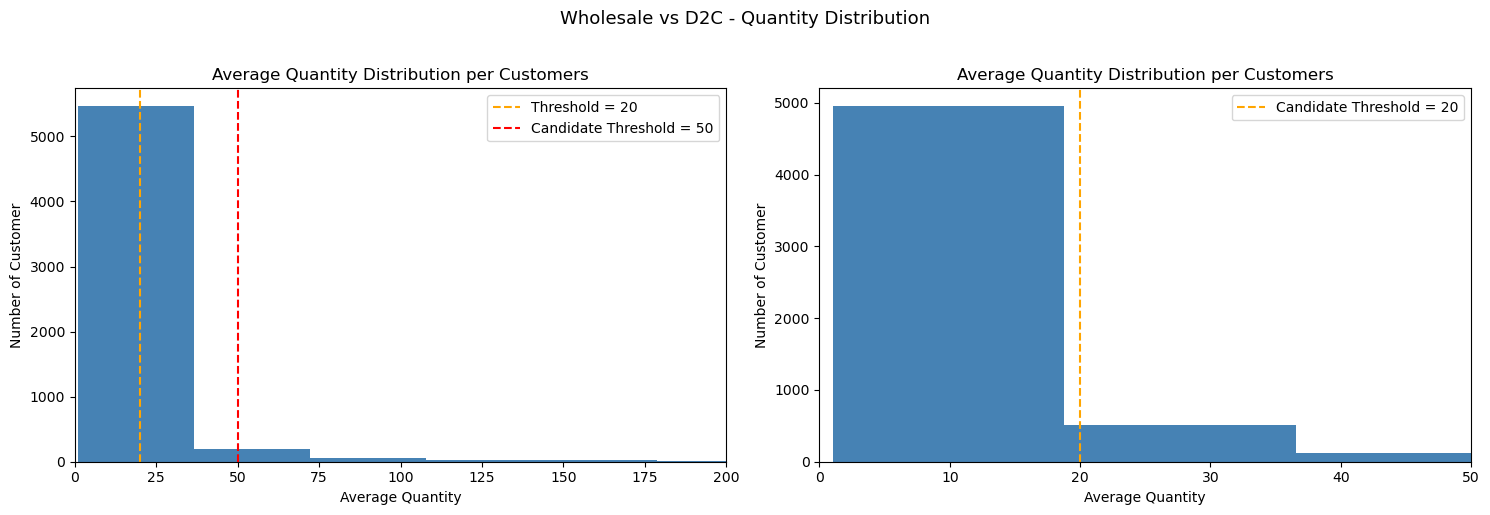

In [7]:
# WHOLESALE IDENTIFICATION
avg_qty = df_customers.groupby('customer_id')['quantity'].mean().reset_index().rename(columns={'quantity': 'avg_qty_per_line'})

# Percentile analysis
percentiles = [25, 50, 75, 90, 95, 99]
pct_values = np.percentile(avg_qty['avg_qty_per_line'], percentiles)

print("=== WHOLESALE THRESHOLD — PERCENTILE ANALYSIS ===")
for p, v in zip(percentiles, pct_values):
    print(f"  {p:>2}%:  {v:>7.1f} avg qty/line")

print(f"\n  Mean:   {avg_qty['avg_qty_per_line'].mean():>7.1f}")
print(f"  Median: {avg_qty['avg_qty_per_line'].median():>7.1f}")
print(f"  Std:    {avg_qty['avg_qty_per_line'].std():>7.1f}")
print(f"\n  → Threshold = 20 sits at P{np.searchsorted(np.sort(avg_qty['avg_qty_per_line']), 20) / len(avg_qty) * 100:.0f} (business judgment, not statistically derived)")

print(f"\n=== QUANTITY DISTRIBUTION ===")
print(f'\nAverage Quantity Order > 10:    {(avg_qty['avg_qty_per_line']>10).sum():,} customers')
print(f'Average Quantity Order > 20:    {(avg_qty['avg_qty_per_line']>20).sum():,} customers')
print(f'Average Quantity Order > 50:    {(avg_qty['avg_qty_per_line']>50).sum():,} customers')

# Visualization
fig, axes = plt.subplots(1,2,figsize=(15,5))

axes[0].hist(avg_qty['avg_qty_per_line'], bins=100, color='steelblue')
axes[0].set_xlim(0,200)
axes[0].set_title('Average Quantity Distribution per Customers')
axes[0].set_xlabel('Average Quantity')
axes[0].set_ylabel('Number of Customer')
axes[0].axvline(x=20, color='orange', linestyle='--',
                label=f'Threshold = 20')
axes[0].axvline(x=50, color='red', linestyle='--', label='Candidate Threshold = 50')
axes[0].legend()

axes[1].hist(avg_qty['avg_qty_per_line'], bins=200, color='steelblue')
axes[1].set_xlim(0,50)
axes[1].set_title('Average Quantity Distribution per Customers')
axes[1].set_xlabel('Average Quantity')
axes[1].set_ylabel('Number of Customer')
axes[1].axvline(x=20, color='orange', linestyle='--', label='Candidate Threshold = 20')
axes[1].legend()

plt.suptitle('Wholesale vs D2C - Quantity Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/charts/01_Wholesale vs D2C - Quantity Distribution')
plt.show()

## Two-Layer Architecture — Why?

After data cleaning, we encounter a critical structural challenge: **~22% of all valid transactions lack a `Customer ID`**. These represent anonymous guest checkouts.

A naive approach would be to drop all rows with missing IDs. However, this forces an unacceptable analytical trade-off depending on the business objective:

| Analytical Goal | Required Data Scope | Action: Drop Anonymous Rows? |
| :--- | :--- | :--- |
| **Product & Revenue Analysis** <br>*(e.g., ABC/XYZ Inventory)* | 100% of commercial transactions. |  **No.** Dropping them artificially deflates revenue and misrepresents true SKU demand. |
| **Customer Behavior Analysis** <br>*(e.g., RFM, Wholesale Labeling)* | Verified user accounts only. |  **Yes.** Anonymous aggregates distort behavioral metrics like purchase frequency and recency. |

To eliminate this trade-off, we implement a **Two-Layer Data Architecture**:

1. **Transaction Layer (`df_transactions`)** * **Scope:** All valid rows retained (including anonymous).
   * **Purpose:** The absolute source of truth for commercial performance. Used for ABC analysis, XYZ demand variability, and top-line revenue reporting. 
2. **Customer Layer (`df_customers`)**
   * **Scope:** Filtered to rows with a known `Customer ID`.
   * **Purpose:** Dedicated to behavioral modeling. Used to safely calculate metrics like Average Basket Size to establish the Wholesale vs. D2C threshold without noise.

**The Synthesis:**
We derive our Wholesale threshold (Avg. Qty > 20 units/line) purely from the *Customer Layer*. We then **map these labels back** onto the *Transaction Layer* via a Left Join. Transactions mapped to a known ID inherit their calculated segment, while the remaining 22% are safely bucketed as `"Anonymous"`. This ensures our final revenue splits are mathematically exhaustive and analytically honest.


=== SEGMENT SUMMARY - CUSTOMERS ===
           customers  avg_qty_mean
segment                           
D2C             5037           8.7
Wholesale        804          94.2

=== SEGMENT SUMMARY - TRANSACTIONS ===
             rows  total_qty    total_rev  rev_pct   qty
segment                                                 
D2C        709601    5651566  10262696.56     52.7  51.4
Unknown    224172     681874   2586718.84     13.3   6.2
Wholesale   70069    4661983   6608081.51     34.0  42.4


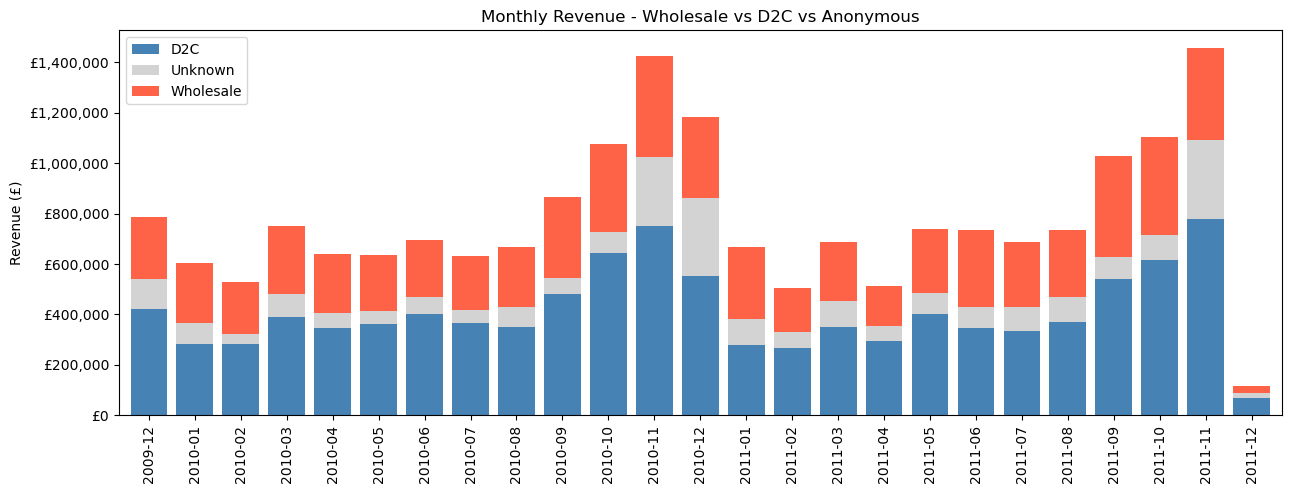

In [8]:
# CUSTOMER LABELING
WHOLESALE_THRESHOLD = 20 # average quantity order greater than 20 is wholesale customer
customer_segments = avg_qty.copy()
customer_segments['segment'] = np.where(avg_qty['avg_qty_per_line']>20, 'Wholesale', 'D2C')

# Merge with Transactions 
df_transactions = df_transactions.merge(customer_segments[['customer_id', 'segment']], on='customer_id', how='left')
df_transactions = df_transactions.fillna('Unknown')

# Merge with Customers 
df_customers = df_customers.merge(customer_segments[['customer_id', 'segment']], on='customer_id', how='left')

print(f'\n=== SEGMENT SUMMARY - CUSTOMERS ===')
seg_summary = customer_segments.groupby('segment').agg(
    customers = ('customer_id', 'count'),
    avg_qty_mean = ('avg_qty_per_line', 'mean')).round(1)
print(seg_summary)

print(f'\n=== SEGMENT SUMMARY - TRANSACTIONS ===')
rev = df_transactions.copy()
rev['revenue'] = df_transactions['quantity'] * df_transactions['price']
split = rev.groupby('segment').agg(
    rows = ('revenue', 'count'),
    total_qty = ('quantity', 'sum'),
    total_rev = ('revenue', 'sum'))
split['rev_pct'] = (split['total_rev'] / split['total_rev'].sum()*100).round(1)
split['qty'] = (split['total_qty'] / split['total_qty'].sum()*100).round(1)
print(split)

# Visualization
df_transactions['revenue'] = df_transactions['quantity'] * df_transactions['price']
df_transactions['yearmonth'] = df_transactions['order_date'].dt.to_period('M')

monthly_segment = df_transactions.groupby(['yearmonth', 'segment'])['revenue'].sum().reset_index()

pivot = monthly_segment.pivot(index='yearmonth', columns='segment', values='revenue').fillna(0)

fig, ax = plt.subplots(figsize=(15,5))
pivot.plot(kind='bar', stacked=True, ax=ax, color={'D2C': 'steelblue', 'Wholesale': 'tomato', 'Unknown': 'lightgray'},width=0.8)

ax.set_title('Monthly Revenue - Wholesale vs D2C vs Anonymous')
ax.set_xlabel('')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:,.0f}'))
ax.legend()

plt.tight_layout
plt.savefig('../outputs/charts/02_Monthly Revenue - Wholesale vs D2C vs Anonymous')
plt.show()

=== ABC CLASSIFICATION ===
  abc_class  num_sku    total_rev  sku_pct  rev_pct
0         A     1020  15563838.47     21.2     80.0
1         B     1269   2919663.17     26.3     15.0
2         C     2531    973995.27     52.5      5.0


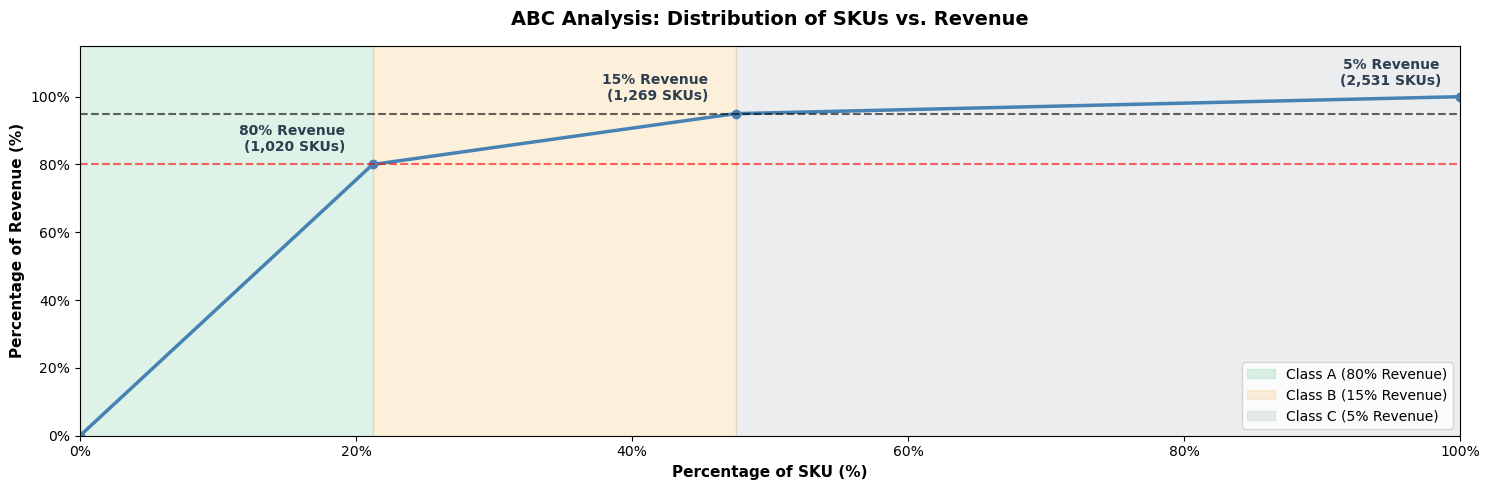

In [ ]:
# ABC ANALYSIS
abc_stats = df_transactions.groupby(['sku']).agg(
    total_rev = ('revenue', 'sum'),
    total_qty = ('quantity', 'sum'),
    description = ('description', 'first')).sort_values('total_rev', ascending=False).reset_index()

abc_stats['cumrev'] = abc_stats['total_rev'].cumsum()
abc_stats['cumrev_pct'] = abc_stats['cumrev'] / abc_stats['total_rev'].sum() * 100

abc_stats['abc_class'] = pd.cut(abc_stats['cumrev_pct'],
                                bins = [0,80,95,100],
                                labels = ['A', 'B', 'C'],
                                include_lowest=True,
                                right=True)

abc_summary = abc_stats.groupby(['abc_class']).agg(
    num_sku = ('sku' , 'count'),
    total_rev = ('total_rev' , 'sum')).reset_index()
abc_summary['sku_pct'] = (abc_summary['num_sku'] / len(abc_stats) * 100).round(1)
abc_summary['rev_pct'] = (abc_summary['total_rev'] / abc_summary['total_rev'].sum() * 100).round(1)

print('=== ABC CLASSIFICATION ===')
print(abc_summary)

# PARETO CHART
fig, ax = plt.subplots(figsize=(15,5))

x_data = [0] + abc_summary['sku_pct'].cumsum().tolist()
y_data = [0] + abc_summary['rev_pct'].cumsum().tolist()

ax.plot(x_data, y_data, marker='o', linewidth=2.5, markersize = 6, color='steelblue')

ax.axvspan(0, abc_summary['sku_pct'].cumsum()[0], alpha=0.15, color='#27ae60', label='Class A (80% Revenue)')
ax.axvspan(abc_summary['sku_pct'].cumsum()[0], abc_summary['sku_pct'].cumsum()[1], alpha=0.15, color='#f39c12', label='Class B (15% Revenue)')
ax.axvspan(abc_summary['sku_pct'].cumsum()[1], abc_summary['sku_pct'].cumsum()[2], alpha=0.15, color='#7f8c8d', label='Class C (5% Revenue)')

ax.axhline(y=80, color='red', linestyle='--', alpha=0.6)
ax.axhline(y=95, color='black', linestyle='--', alpha=0.6)

for i in range(3):
    x_val = abc_summary['sku_pct'].cumsum()[i]
    y_val = abc_summary['rev_pct'][i]
    num_skus = int(abc_summary['num_sku'][i]) 
    
    # Text format
    text_label = f"{y_val:.0f}% Revenue\n({num_skus:,} SKUs)"
    if i == 0:  # Class A
        ax.text(x_val - 2, y_val + 3, text_label,
                fontweight='bold', ha='right', va='bottom', color='#2c3e50', fontsize=10)
    elif i == 1:  # Class B
        ax.text(x_val - 2, y_val + 83, text_label,
                fontweight='bold', ha='right', va='bottom', color='#2c3e50', fontsize=10)
    else:  # Class C
        ax.text(95, 107, text_label,
                fontweight='bold', ha='center', va='center', color='#2c3e50', fontsize=10)


# Labels & Titles
ax.set_title('ABC Analysis: Distribution of SKUs vs. Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Percentage of SKU (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Percentage of Revenue (%)', fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.yaxis.set_major_formatter(PercentFormatter(100))

ax.set_xlim(0, 100)
ax.set_ylim(0, 115)

ax.legend(loc='lower right',fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/03_ABC Analysis Distribution of SKUs vs Revenue.png')
plt.show()

In [10]:
# XYZ ANALYSIS
monthly_sku = df_transactions.groupby(['sku', pd.Grouper(key = 'order_date', freq= 'ME')])['quantity'].sum().reset_index().rename(columns={'quantity' : 'monthly_qty'})

xyz_stats = monthly_sku.groupby('sku')['monthly_qty'].agg(
    mean = 'mean',
    std = 'std',
    active_month = 'count').reset_index()

# CoV calculations (only for SKUs have more than 3 active months of transactions)
xyz_stats = xyz_stats[xyz_stats['active_month'] >= 3].copy()
xyz_stats['CoV'] = (xyz_stats['std'] / xyz_stats['mean']).fillna(0)

# XYZ Classification
xyz_stats['xyz_class'] = pd.cut(xyz_stats['CoV'],
                                bins = [-np.inf,0.5,1,np.inf],
                                labels= ['X' , 'Y' , 'Z'])

xyz_summary = xyz_stats.groupby('xyz_class').agg(
    num_sku = ('sku' , 'count'),
    avg_cv = ('CoV' , 'mean')).reset_index()
xyz_summary['sku_pct'] = (xyz_summary['num_sku'] / len(xyz_stats) * 100).round(1)

print('=== XYZ CLASSIFICATION ===')
print(xyz_summary)

=== XYZ CLASSIFICATION ===
  xyz_class  num_sku    avg_cv  sku_pct
0         X      365  0.396747      8.4
1         Y     2179  0.749436     49.9
2         Z     1822  1.502088     41.7


In [11]:
# ABC-XYZ CLASSIFICATION

# Merge abc_stats and xyz_stats
sku_stats = abc_stats.merge(xyz_stats[['sku', 'CoV', 'xyz_class', 'active_month']], on= 'sku', how='left')

sku_stats['xyz_class'] = sku_stats['xyz_class'].fillna('Z')

sku_stats['abc_xyz'] = sku_stats['abc_class'].astype(str) + sku_stats['xyz_class'].astype(str)

sku_stats.head()

# ABC-XYZ Matrix
abcxyz_matrix = sku_stats.groupby(['abc_class', 'xyz_class']).agg(
    num_sku = ('sku', 'count'),
    total_rev = ('total_rev' , 'sum')).reset_index()
abcxyz_matrix['rev_pct'] = (abcxyz_matrix['total_rev'] / abcxyz_matrix['total_rev'].sum() * 100).round(1)

print('=== ABC-XYZ MATRIX ===')
print(abcxyz_matrix)

=== ABC-XYZ MATRIX ===
  abc_class xyz_class  num_sku   total_rev  rev_pct
0         A         X      136  3225763.04     16.6
1         A         Y      616  9055632.08     46.5
2         A         Z      268  3282443.35     16.9
3         B         X       52   128752.68      0.7
4         B         Y      610  1466927.94      7.5
5         B         Z      607  1323982.55      6.8
6         C         X      177    37095.73      0.2
7         C         Y      953   380839.30      2.0
8         C         Z     1401   556060.24      2.9


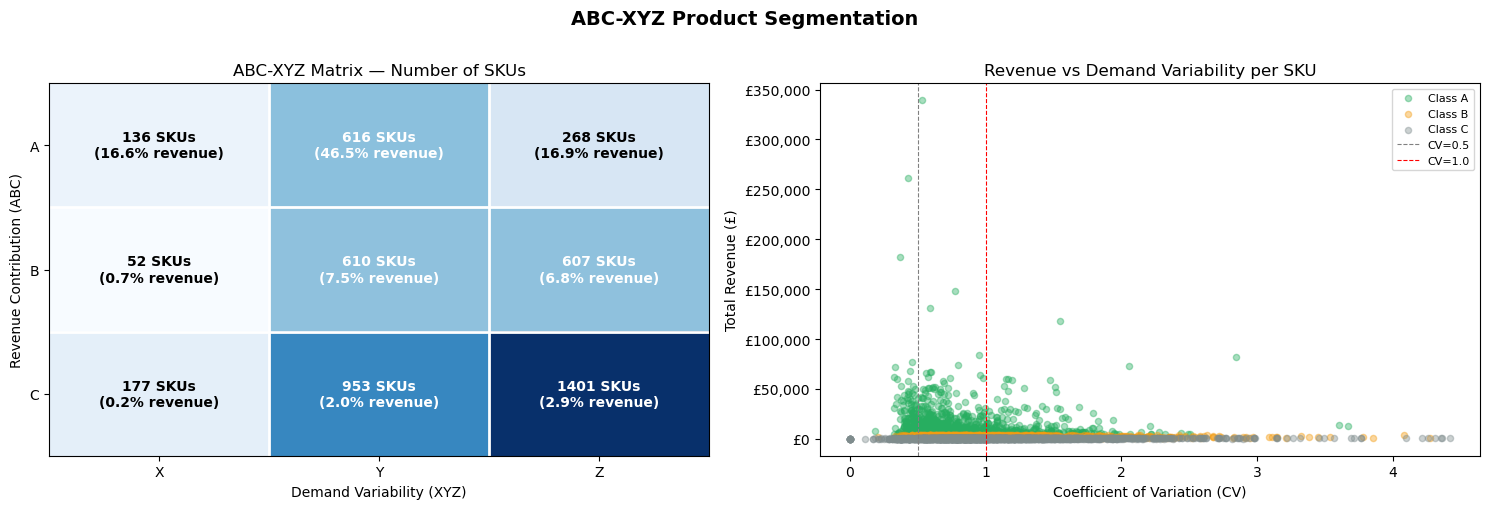

=== INVENTORY POLICY RECOMMENDATIONS ===
  AX │ 136 SKUs · 16.6% revenue       │ Lean inventory · Low safety stock · Simple forecast
  AY │ 616 SKUs · 46.5% revenue       │ Moderate buffer · Monitor seasonality · Priority NB03
  AZ │ 268 SKUs · 16.9% revenue       │ High safety stock · Advanced forecast · Highest risk
  BX │ 52 SKUs ·  0.7% revenue        │ Standard policy · Low priority
  BY │ 610 SKUs · 7.5% revenue        │ Standard policy · Review quarterly
  BZ │ 607 SKUs ·  6.8% revenue       │ Reduce SKU count · Safety stock review
  CX │ 177 SKUs ·  0.2% revenue       │ Minimal stock · Consider phase-out
  CY │ 953 SKUs · 2.0% revenue        │ Minimal stock · Review necessity
  CZ │ 1401 SKUs · 2.9% revenue       │ Discontinue candidates · No safety stock


In [15]:
# ABC-XYZ HEATMAP MATRIX
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Chart 1: Heatmap by SKUs ---
heatmap_data = abcxyz_matrix.pivot(index='abc_class', columns='xyz_class', values='num_sku')
heatmap_data = heatmap_data.reindex(index=['A','B','C'], columns=['X','Y','Z'])

im = axes[0].imshow(heatmap_data.values, cmap='Blues', aspect='auto')
axes[0].set_xticks([0,1,2]); axes[0].set_xticklabels(['X','Y','Z'])
axes[0].set_yticks([0,1,2]); axes[0].set_yticklabels(['A','B','C'])
axes[0].set_title('ABC-XYZ Matrix — Number of SKUs', fontsize=12)
axes[0].set_xlabel('Demand Variability (XYZ)')
axes[0].set_ylabel('Revenue Contribution (ABC)')

# White grid lines
axes[0].set_xticks([0.5, 1.5], minor=True)
axes[0].set_yticks([0.5, 1.5], minor=True)
axes[0].grid(which="minor", color="white", linestyle='-', linewidth=2)
axes[0].tick_params(which="minor", bottom=False, left=False)

for i in range(3):
    for j in range(3):
        val = heatmap_data.values[i, j]
        rev = abcxyz_matrix[(abcxyz_matrix['abc_class']==(['A','B','C'][i]) ) & 
                     (abcxyz_matrix['xyz_class']==(['X','Y','Z'][j]))]['rev_pct'].values
        rev_str = f"\n({rev[0]}% revenue)" if len(rev) > 0 else ""
        axes[0].text(j, i, f"{int(val)} SKUs{rev_str}", 
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white' if val > 400 else 'black')

# --- Chart 2: Scatter Revenue vs CV ---
colors = {'A': "#27ae60", 'B': "#f39c12", 'C': "#7f8c8d"}
for abc_class in ['A', 'B', 'C']:
    subset = sku_stats[sku_stats['abc_class'] == abc_class]
    axes[1].scatter(subset['CoV'], subset['total_rev'],
                   alpha=0.4, s=20, label=f'Class {abc_class}',
                   color=colors[abc_class])

axes[1].axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, label='CV=0.5')
axes[1].axvline(x=1.0, color='red',  linestyle='--', linewidth=0.8, label='CV=1.0')
axes[1].set_title('Revenue vs Demand Variability per SKU', fontsize=12)
axes[1].set_xlabel('Coefficient of Variation (CV)')
axes[1].set_ylabel('Total Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].legend(fontsize=8)

plt.suptitle('ABC-XYZ Product Segmentation', fontsize=14, weight = 'bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/charts/04_ABC-XYZ Product Segmentation', dpi=150, bbox_inches='tight')
plt.show()

# POLICY TABLE
print("=== INVENTORY POLICY RECOMMENDATIONS ===")
policy = {
    'AX': ('136 SKUs · 16.6% revenue', 'Lean inventory · Low safety stock · Simple forecast'),
    'AY': ('616 SKUs · 46.5% revenue', 'Moderate buffer · Monitor seasonality · Priority NB03'),
    'AZ': ('268 SKUs · 16.9% revenue', 'High safety stock · Advanced forecast · Highest risk'),
    'BX': ( '52 SKUs ·  0.7% revenue', 'Standard policy · Low priority'),
    'BY': ('610 SKUs · 7.5% revenue', 'Standard policy · Review quarterly'),
    'BZ': ('607 SKUs ·  6.8% revenue', 'Reduce SKU count · Safety stock review'),
    'CX': ('177 SKUs ·  0.2% revenue', 'Minimal stock · Consider phase-out'),
    'CY': ('953 SKUs · 2.0% revenue', 'Minimal stock · Review necessity'),
    'CZ': ('1401 SKUs · 2.9% revenue', 'Discontinue candidates · No safety stock'),}
for group, (size, action) in policy.items():
    print(f"  {group} │ {size:<30} │ {action}")

## ABC-XYZ Segmentation Summary:
- AY group (616 SKUs) = 46.5% of revenue — largest revenue concentration, moderate volatility → highest business priority
- AZ group (268 SKUs) = 16.9% of revenue — high value + high volatility → requires advanced forecast
- CZ group (1401  SKUs) = 2.9% of revenue — 29.1% of total SKUs but only 2.9% of revenue → discontinue candidates
- Scatter plot: Class A SKUs are concentrated at CV < 1.5 — no AX/AY SKUs have extremely high CV → manageable

In [17]:
# EXPORT ABC-XYZ CLASSIFICATION
sku_stats.to_csv('../outputs/files/abc_xyz_classification.csv', index=False)

print("=== EXPORT COMPLETE ===")
print(f"abc_xyz_classification.csv: {len(sku_stats):,} SKUs")
print(f"\nColumns: {list(sku_stats.columns)}")
print(f"\nABC-XYZ distribution:")
print(sku_stats['abc_xyz'].value_counts().sort_index())

=== EXPORT COMPLETE ===
abc_xyz_classification.csv: 4,820 SKUs

Columns: ['sku', 'total_rev', 'total_qty', 'description', 'cumrev', 'cumrev_pct', 'abc_class', 'CoV', 'xyz_class', 'active_month', 'abc_xyz']

ABC-XYZ distribution:
abc_xyz
AX     136
AY     616
AZ     268
BX      52
BY     610
BZ     607
CX     177
CY     953
CZ    1401
Name: count, dtype: int64
